## 3. Deskriptive Statistik und Visualisierungen

In [9]:
import pandas as pd
df = pd.read_csv('../data/Library_Usage.csv',na_values="Null",
                 low_memory=False
                )
df['Age Range'].value_counts()

Age Range
25 to 34 years       95278
35 to 44 years       85669
10 to 19 years       67758
45 to 54 years       49820
0 to 9 years         33180
65 to 74 years       32455
20 to 24 years       27145
75 years and over    20721
55 to 59 years       19735
60 to 64 years       18088
Name: count, dtype: int64

In [3]:
df['Age Range'].value_counts(normalize=True)

Age Range
25 to 34 years       0.211800
35 to 44 years       0.190439
10 to 19 years       0.150624
45 to 54 years       0.110748
0 to 9 years         0.073758
65 to 74 years       0.072146
20 to 24 years       0.060342
75 years and over    0.046062
55 to 59 years       0.043870
60 to 64 years       0.040209
Name: proportion, dtype: float64

In [7]:
age_mode = df['Age Range'].mode()
age_mode[0]

'25 to 34 years'

### 3.1 Häufigkeiten

Erstelle eine Häufigkeitsverteilung für die Variable 'Year Patron Registered'. Wieviel Prozent der Kunden wurden 2013 im System registriert? Wie viele in den kommenden Jahren? Was fällt Dir auf?

In [11]:
year_registered_statistics = df['Year Patron Registered'].value_counts(normalize = True)
print(year_registered_statistics)

Year Patron Registered
2023    0.132654
2022    0.115015
2003    0.088927
2021    0.072678
2019    0.072502
2020    0.065870
2017    0.064515
2018    0.062939
2016    0.048117
2015    0.043767
2014    0.033917
2013    0.028750
2012    0.027600
2011    0.026841
2009    0.024580
2010    0.024363
2008    0.021705
2007    0.014033
2006    0.011302
2005    0.010263
2004    0.009661
Name: proportion, dtype: float64


In [18]:
round(year_registered_statistics[2013], 2)

0.03

Ersetze die fehlenden Werte in der Spalte Age Range durch den Modus dieser Spalte. Nutze dazu die Funktion DataFrame.fillna (siehe hier für die Dokumentation).

In [28]:
df['Age Range'] = df['Age Range'].fillna(df['Age Range'].mode()[0], inplace=True)

In [30]:
df['Age Range'].isnull().value_counts()

Age Range
True    450359
Name: count, dtype: int64

Denkst Du, es handelt sich dabei um eine gute Methode, fehlende Werte zu ersetzen? Welche anderen Strategien fallen Dir ein?
Nicht wirklich, da es fehlende Werte mit der häufigsten Angabe ersetzt. Besser wäre diese mit dem Mittelwert zu ersetzen oder bei zu vielen fehlenden Angaben die Datensätze zu löschen. 

### 3.2 Mittelwert und Median

Schau Dir den Mittelwert und den Median der Variable Total Checkouts an. Warum sind die beiden Werte so unterschiedlich?
Was ziehst Du daraus für Schlüsse für weitere statistische Analysen und Reports?

In [39]:
df['Total Checkouts'].mean()

155.218052709061

In [41]:
df['Total Checkouts'].median()

7.0

Es scheint sehr viele Ausreißer zu geben, die den Mittelwert in die Höhe schießen lassen. 

In [56]:
df['Total Checkouts'].quantile(q=[0.25, 0.5, 0.75])

0.25     0.0
0.50     7.0
0.75    74.0
Name: Total Checkouts, dtype: float64

In [58]:
alpha = 0.005
df['Total Checkouts'].quantile([alpha, 1-alpha])

0.005       0.0
0.995    3255.0
Name: Total Checkouts, dtype: float64

### 3.3 Exkurs: Ausreißerentfernung I (30 Min)
Identifziere jeweils die 1.5% größten Werte in der Spalte Total Checkouts. Definiere diese Werte als Ausreißer.
Erstelle einen Datensatz, für den diese Ausreißer entfernt sind.
Handelt es sich hierbei um eine gute Methode, Ausreißer zu identifizieren und zu behandeln? Welche anderen Strategien kennst Du?

In [5]:
df['Total Checkouts'].describe()

count    450359.000000
mean        155.218053
std         526.242567
min           0.000000
25%           0.000000
50%           7.000000
75%          74.000000
max       39743.000000
Name: Total Checkouts, dtype: float64

In [33]:
alpha = 0.015
q_low = df['Total Checkouts'].quantile(alpha)
q_high = df['Total Checkouts'].quantile(1 - alpha)
df_no_1_5_outliers = df[(df['Total Checkouts'] < q_high) & (df['Total Checkouts'] > q_low)]

In [35]:
df_no_1_5_outliers['Total Checkouts'].mean()

159.64211655345014

In [39]:
# Wie viele Datensätze wurden entfernt?
print(len(df) - len(df_no_1_5_outliers))

153877


In [ ]:
Q1 = np.percentile(df['Total Checkouts'], 25, interpolation="midpoint")
Q3 = np.percentile(df['Total Checkouts'], 75, interpolation="midpoint")

upper_bound = df['Total Checkouts'] >= (Q3 + 1.5 * IQR)
lower_bound = df['Total Checkouts'] <= (Q1 - 1.5 * IQR)

In [76]:
# Besser wäre: 
# outliers = (data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))
#test

### 3.4 Varianz
Welche Variable streut mehr: 'Total Checkouts' oder 'Total Renewals'? Vergleiche die Standardabweichungen und den Variationskoeffizienten miteinander.

In [51]:
df['Total Checkouts'].std()

526.2425672959899

In [47]:
df['Total Checkouts'].var()

276931.23963427445

In [53]:
df['Total Renewals'].std()

305.91523273880455

In [49]:
df['Total Renewals'].var()

93584.12962163695

In [55]:
df['Total Checkouts'].std()/df['Total Checkouts'].mean()

3.390343829930486

In [58]:
df['Total Renewals'].std()/df['Total Renewals'].mean()

3.873868313954441

### 3.5 Exkurs: Ausreißerentfernung II
Identifiziere positive Ausreißer in der Spalte Total Checkouts. Ausreißer werden jetzt als Beobachtungen xi
 definiert, für die gilt:
xi>x0.75+1.5xIQR
Das heißt, eine Beobachtungen gilt als Ausreißer, wenn sie größer als die Summe aus dem 75% Quantil und dem 1.5-fachen des Interquartilsabstands ist.
Wie viel Prozent der Beobachtungen im Datensatz werden mit dieser Methode als Ausreißer markiert?

In [64]:
q3 = df['Total Checkouts'].quantile(q=0.75)
q1 = df['Total Checkouts'].quantile(q=0.25)

iqr = q3 - q1

lower_range = q1 - 1.5 * iqr
upper_range = q3 + 1.5 * iqr
outlier_free_df =  df[(df['Total Checkouts'] < upper_range ) & (df['Total Checkouts'] > lower_range)]

In [92]:
round(100 - len(outlier_free_df) / len(df) * 100, 2)

16.08

### 3.6 Symmetrie und Schiefe (15 Min)
Schau Dir die verschiedenen Histogramme im Bild an und charakterisiere jede einzelne Verteilung anhand von Schiefe, Symmetrie und Modus
Die Grafik wurde mit dem oben angehängten Jupyter Notebook generiert. Hier kannst Du auch selber andere Verteilungen simulieren und visualisieren.

1: symmetrische Verteilungen, bimodal
2: linkssteile (rechtschiefe) Verteilung, unimodal
3: linkssteile (rechtschiefe) Verteilung, unimodal
4: rechtssteile (linksschiefe) Verteilung, unimodal
5: symmetrische Verteilung, kein Modus
6: linkssteile (rechtschiefe) Verteilung, unimodal
7: rechtssteile (linksschiefe) Verteilung, unimodal
8: rechtssteile (linksschiefe) Verteilung, unimodal
9: beinahe symmetrische Verteilung, leicht rechtssteile (linksschiefe) Verteilung, unimodal

### 3.7 Exkurs: Ausreißerentfernung III (30 Min)
Erstelle eine neue Spalte 'Total Checkouts Sqrt', die die Wurzel über die Spalte Total Checkouts enthält. Die Wurzel für jede Beobachtung kannst Du mit df['Total Checkouts']**(0.5) berechnen.
Schaue Dir das Histogramm von 'Total Checkouts Sqrt' an und charakterisiere die Verteilung.
Vergleiche diese Methode mit den vorherigen zwei Verfahren zur Ausreißerbehandlung (Aufgaben 3.3 und 3.5). Welche Methode findest Du besser geeignet, um mit fehlenden Werten umzugehen?
Fallen Dir Vor- und Nachteile der jeweiligen Methoden ein?

In [11]:
df["Total Checkouts Sqrt"] = df['Total Checkouts']**(0.5)

<Axes: >

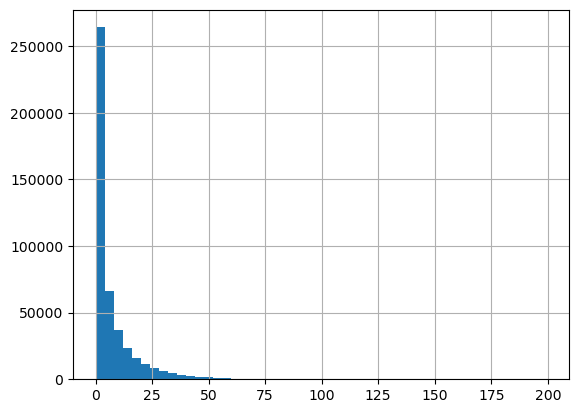

In [25]:
df["Total Checkouts Sqrt"].hist(bins=50)

Es handelt sich um eine rechtssteile, linksschiefe, unimodale Verteilung. 

### Kreuztabellen

In [31]:
pd.crosstab(
    df['Notice Preference Definition'],
    df['Age Range'],
    margins=True
)

Age Range,0 to 9 years,10 to 19 years,20 to 24 years,25 to 34 years,35 to 44 years,45 to 54 years,55 to 59 years,60 to 64 years,65 to 74 years,75 years and over,All
Notice Preference Definition,,,,,,,,,,,
Email,30075,56115,24544,90890,81600,46797,18086,16091,27987,16437,408622
Phone,1580,10494,2150,2675,2452,2122,1261,1577,3700,3676,31687
Print,1030,628,263,1000,968,596,279,299,627,542,6232
All,32685,67237,26957,94565,85020,49515,19626,17967,32314,20655,446541


In [ ]:
pd.crosstab(
    df['Notice Preference Definition'],
    df['Age Range'],
    margins=True, normalize=0
)

### Korrelation

In [34]:
df['Total Checkouts'].corr(df['Total Renewals'])

0.6421628513121922

### 3.8 Exkurs: Anscombe-Quartett (30 Min)
Das Anscombe Quartett ist ein Datenstatz, der aus 4 bivariaten Verteilungen besteht. Über die Spaltennamen ['x1', 'y1'], ['x2', 'y2'], ..., ['x4', 'y4'] können die zusammengehörenden Datenpaare ausgewählt werden.

Lies den Datensatz ein.
Berechne den Mittelwert, Median und die Standardabweichung der Spalten.
Berechne jeweils die Korrelation zweier zusammenhängender Spalten [x<i>, y<i>].
Erstelle jeweils ein Streudiagram zweier zusammenhängender Spalten [x<i>, y<i>].
Was fällt Dir auf? Informiere Dich über den Datensatz hier.

In [37]:
df_anscombe = pd.read_csv('../data/anscombe.csv',na_values="Null",
                 low_memory=False
                )

In [39]:
df_anscombe

,x1,y1,x2,y2,x3,y3,x4,y4
0,10,8.04,10,9.14,10,7.46,8,6.58
1,8,6.95,8,8.14,8,6.77,8,5.76
2,13,7.58,13,8.74,13,12.74,8,7.71
3,9,8.81,9,8.77,9,7.11,8,8.84
4,11,8.33,11,9.26,11,7.81,8,8.47
5,14,9.96,14,8.10,14,8.84,8,7.04
6,6,7.24,6,6.13,6,6.08,8,5.25
7,4,4.26,4,3.10,4,5.39,19,12.50
8,12,10.84,12,9.13,12,8.15,8,5.56
9,7,4.82,7,7.26,7,6.42,8,7.91


In [41]:
df_anscombe.mean()

x1    9.000000
y1    7.500909
x2    9.000000
y2    7.500909
x3    9.000000
y3    7.500000
x4    9.000000
y4    7.500909
dtype: float64

In [43]:
df_anscombe.median()

x1    9.00
y1    7.58
x2    9.00
y2    8.14
x3    9.00
y3    7.11
x4    8.00
y4    7.04
dtype: float64

In [45]:
df_anscombe.std()

x1    3.316625
y1    2.031568
x2    3.316625
y2    2.031657
x3    3.316625
y3    2.030424
x4    3.316625
y4    2.030579
dtype: float64

In [47]:
df_anscombe['x1'].corr(df_anscombe['y1'])

0.81642051634484

In [53]:
df_anscombe['x2'].corr(df_anscombe['y1'])

0.81642051634484

In [55]:
import seaborn as sns

<Axes: xlabel='x1', ylabel='y1'>

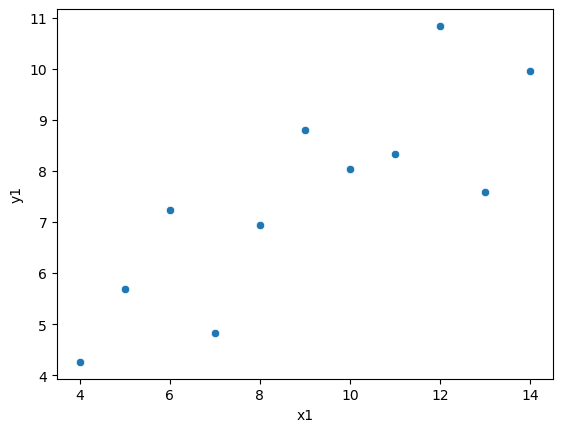

In [71]:
sns.scatterplot(x='x1', y='y1', data=df_anscombe)

<Axes: xlabel='x3', ylabel='y3'>

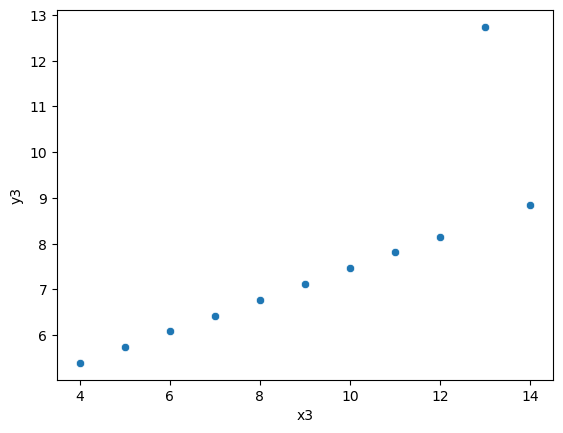

In [73]:
sns.scatterplot(x='x3', y='y3', data=df_anscombe)

### Visualisierungen mit Seaborn

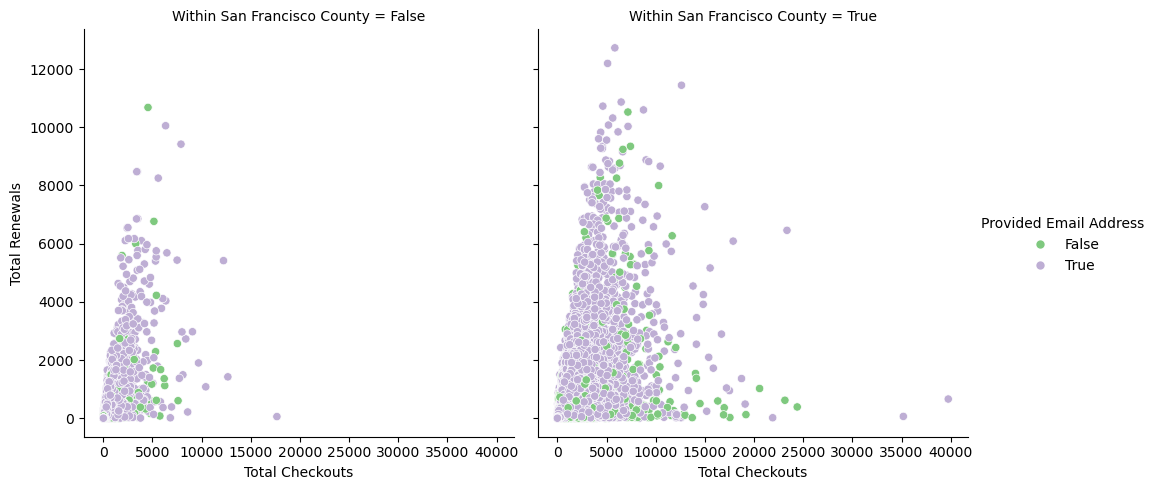

In [76]:
sns.relplot(x='Total Checkouts', y='Total Renewals', 
            hue='Provided Email Address', 
            col='Within San Francisco County',
            palette=sns.color_palette('Accent', 2), 
            data=df)

/opt/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 26.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


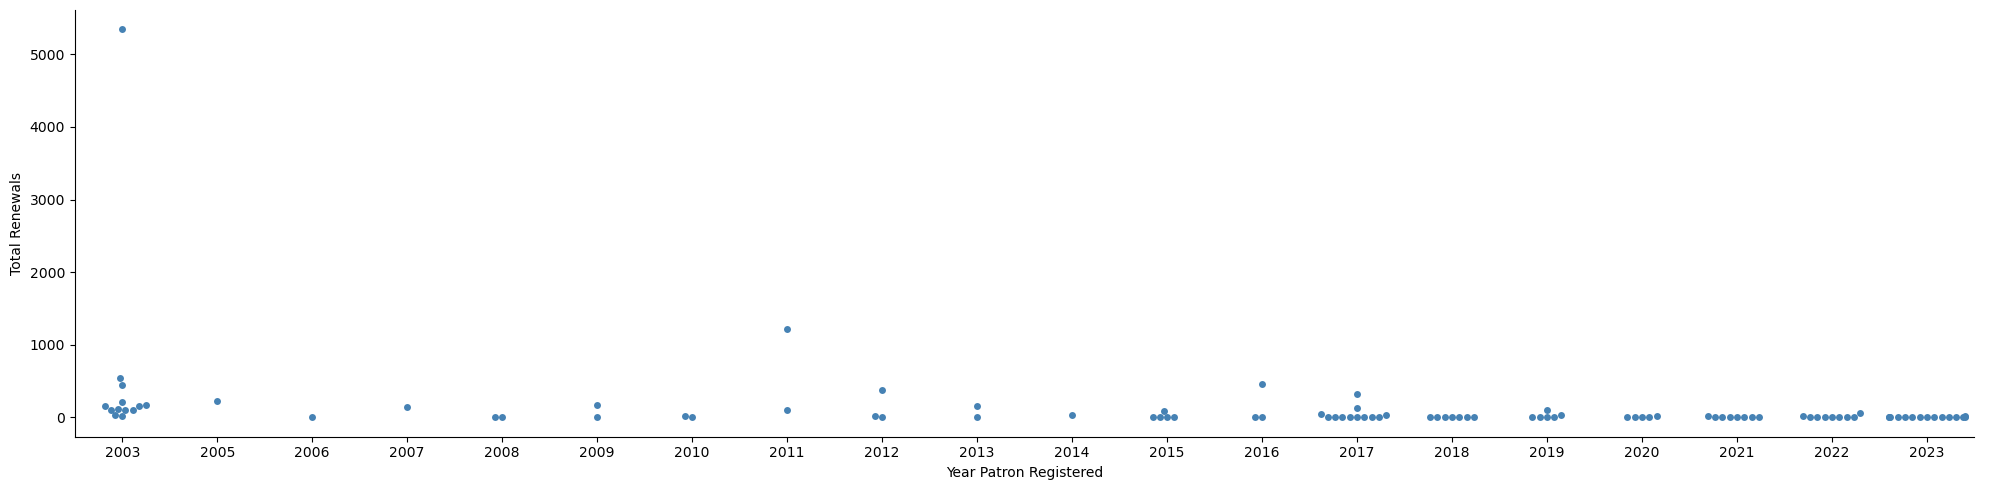

In [80]:
# Swarmplot
df_small_sample = pd.read_csv("../data/Library_Usage.csv",low_memory=False,na_values="Null").sample(n=100)
sns.catplot(x='Year Patron Registered', y = 'Total Renewals',
            data=df_small_sample, kind='swarm', color="steelblue", aspect=4)